Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

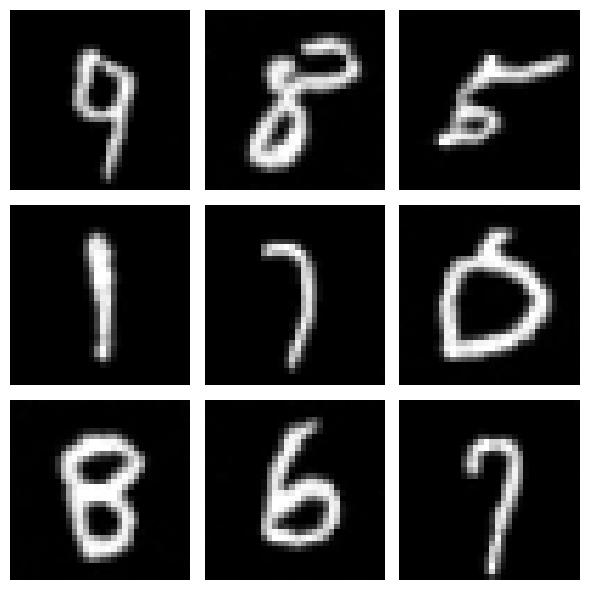

In [10]:
import torch
from torchvision import transforms

from models.unet import DDPMUNet
from models.ddpm import DDPM

from tqdm.auto import tqdm

from PIL import Image
import matplotlib.pyplot as plt

def sample(num_samples: int, ddpm: DDPM, device: torch.device) -> list[Image.Image]:
    ddpm.eval()
    with torch.no_grad():
        x_t = torch.randn(num_samples, 1, 32, 32, device=device)
        for t in tqdm(range(ddpm.timesteps - 1, -1, -1), desc='Sampling'):
            if t > 0:
                z = torch.randn_like(x_t, device=device)
            else:
                z = torch.zeros_like(x_t, device=device)

            t_tensor = torch.full((num_samples,), t, device=device)
            x_t = ddpm.p_sample(x_t, t_tensor, z)
        
        x_t = x_t.clamp(0, 1)
        transform = transforms.ToPILImage()
        img_list = []
        for i in range(num_samples):
            img = transform(x_t[i].cpu())
            img_list.append(img)
    return img_list


if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    ddpm_unet = DDPMUNet(1, 128, num_res_blocks=3)
    ddpm = DDPM(1000, ddpm_unet).to(device)
    ddpm.load_state_dict(torch.load('./model_ckpts/ddpm.pth', map_location=device))

    img_list = sample(9, ddpm, device)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(img_list[i], cmap='gray')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()